# Setup check

Run this first on every new setup folder. It answers two questions: **is the
data clean**, and **does the physics show up**? `02_predictor.ipynb` builds the
fill predictor on top of the same runs.

Set `DATA_DIR` to one setup folder under `data/` and run top to bottom.

What it does:

1. loads every run and reads the scale factors out of each file's own header
2. finds the taps in each recording
3. averages the spectrum across all taps at each fill level
4. tracks the table peak as water goes in
5. checks that shift against `1/f² ∝ mass`, which predicts the bucket's own mass
6. compares the two boards (the ratio dip)
7. mount check
8. data quality

Step 5 is the real test. If the inferred bucket mass comes out near the
bucket's actual mass, the physics is behaving. If it comes out negative or
wildly wrong, whatever is moving in the spectrum is not a mass effect.

**Keep one folder per physical setup.** Moving a board, the bucket, the
erasers or the tap spot changes the spectrum as much as the water does, so
runs from different setups can't be compared. New arrangement, new folder,
with a `setup.md` describing it. Terms (table peak, ratio dip, mass mode) are
defined in `CONTEXT.md`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

import tapkit as tk
from tapkit import hhmm

DATA_DIR = "data/2026-09-20_bucket-on-erasers"   # one setup folder

# Band to hunt for the resonance in. Widen it on the first pass, then narrow
# once you can see where the peak actually lives.
PEAK_BAND = (10.0, 150.0)

# With two boards, steps 3-5 use only this one -- the board nearest the
# bucket. The other board has no bucket resonance to find, so including it
# would drag the fit onto the table's own modes. Step 6 uses both.
PRIMARY_BOARD = "A"

# Mass that bounces on the erasers when the bucket is empty, kg: the bucket
# (838 g) plus a third of the erasers (22.5 g total). Only a third, because
# the eraser bottoms sit still on the table and only their tops move with the
# bucket. Only used to check the fit in step 5.
BUCKET_KG = 0.838

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Load the runs

Scale factors come from each file's own header, so a range change between runs can't silently corrupt the comparison.

In [2]:
runs = tk.load_setup(DATA_DIR)

if not runs:
    print(f"No run_*.csv found in {DATA_DIR}")
else:
    print(f"{len(runs)} runs loaded\n")
    for r in runs:
        print(f"  {r['name']:46s} {r['lvl']:>9s}  t{r['trial']}  {hhmm(r)}  "
              f"{r['sweep']:>4s}-sweep  board {r['board']}  {len(r['df']):6d} samples  "
              f"{r['fs']:7.1f} Hz  mount={r['mount']}")

    seen = {}
    for r in runs:
        seen.setdefault((r["water_g"], r["trial"], r["board"]), []).append(r)
    dup = {k: v for k, v in seen.items() if len(v) > 1}
    if dup:
        print("\nSame fill + trial + board recorded more than once:")
        for (_, t, b), rs in dup.items():
            times = ", ".join(hhmm(x) for x in rs)
            print(f"    {rs[0]['lvl']}, trial {t}, board {b}: {times}")
        print("  Use --trial 2, 3... for repeats. If these came from different")
        print("  setups, move the old ones into another folder.")

28 runs loaded

  run_cups000_trial1_A_20260920_232712.csv          0 cups  t1  23:27    up-sweep  board A   29982 samples    999.0 Hz  mount=tape
  run_cups000_trial1_B_20260920_232712.csv          0 cups  t1  23:27    up-sweep  board B   29848 samples   1000.0 Hz  mount=tape
  run_cups000_trial2_A_20260920_233211.csv          0 cups  t2  23:32    up-sweep  board A   29951 samples    999.0 Hz  mount=tape
  run_cups000_trial2_B_20260920_233211.csv          0 cups  t2  23:32    up-sweep  board B   29843 samples   1000.0 Hz  mount=tape
  run_oz050_trial1_A_20260920_233736.csv             50 oz  t1  23:37    up-sweep  board A   29954 samples    999.0 Hz  mount=tape
  run_oz050_trial1_B_20260920_233736.csv             50 oz  t1  23:37    up-sweep  board B   29848 samples   1000.0 Hz  mount=tape
  run_oz100_trial1_A_20260920_234054.csv            100 oz  t1  23:40    up-sweep  board A   29953 samples    999.0 Hz  mount=tape
  run_oz100_trial1_B_20260920_234054.csv            100 oz  t1  23:

## 2. Find the taps

A tap is a short burst well above the resting noise. The refractory period stops one tap being counted twice as it rings down.

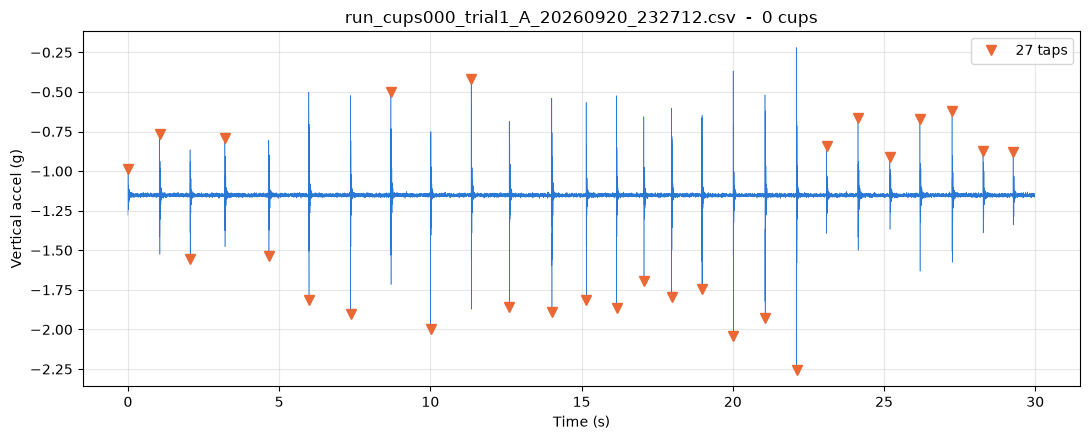

27 taps, mean spacing 1.13 s


In [3]:
r = runs[0]
x = r["df"]["mpu_az"].values
taps = tk.find_taps(x, r["fs"])

fig, ax = plt.subplots()
ax.plot(r["df"]["t_s"], x, lw=0.4, color="#2a78d6")
ax.plot(r["df"]["t_s"].values[taps], x[taps], "v", color="#eb6834",
        ms=7, label=f"{len(taps)} taps")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Vertical accel (g)")
ax.set_title(f"{r['name']}  -  {r['lvl']}")
ax.legend()
plt.tight_layout(); plt.show()

print(f"{len(taps)} taps, mean spacing "
      f"{np.mean(np.diff(taps)) / r['fs']:.2f} s" if len(taps) > 1 else "too few taps")

## 3. Average the spectrum over taps

Each tap is one noisy estimate of the same impulse response, so averaging
their power spectra beats any single tap. The exponential window forces the
response to zero by the window's end, which stops truncation from smearing
the peak — standard practice in modal testing. It adds a known, uniform bit
of damping, so peaks look slightly broader than they are, but their
*frequencies* are unaffected.

steps 3-5 use board A only (14 of 28 runs)


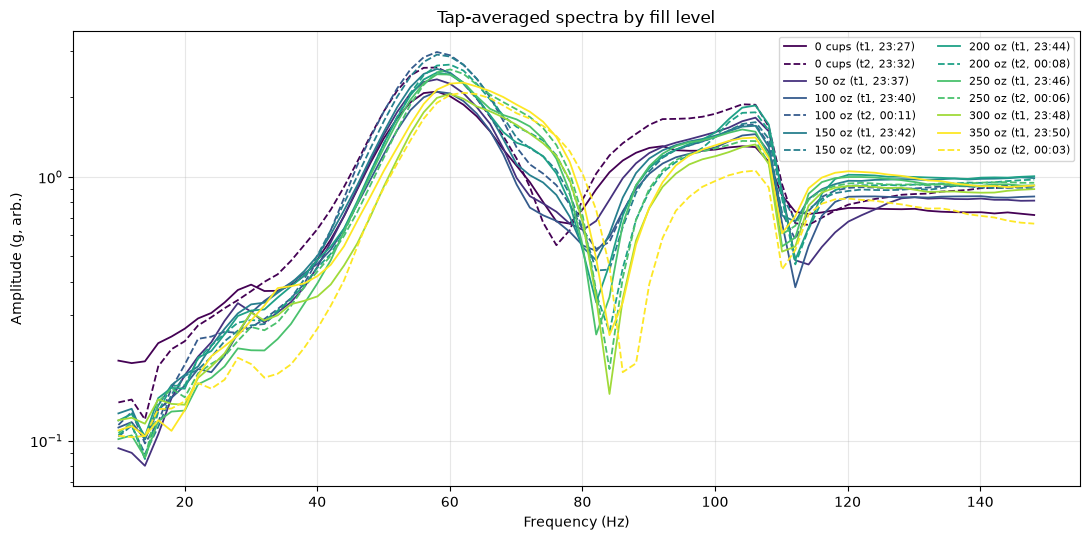

In [4]:
tk.add_spectra(runs)
fig, ax = plt.subplots(figsize=(11, 5.5))
cmap = plt.get_cmap("viridis")
primary = [r for r in runs if r["board"] == PRIMARY_BOARD] or runs
if len(primary) < len(runs):
    print(f"steps 3-5 use board {PRIMARY_BOARD} only "
          f"({len(primary)} of {len(runs)} runs)")

levels = sorted({r["water_g"] for r in primary})
repeat = {}   # repeats at the same fill level get a different line style
for r in sorted(primary, key=lambda r: r["water_g"]):
    if r["n_taps"] == 0:
        continue
    frac = levels.index(r["water_g"]) / max(len(levels) - 1, 1)
    m = (r["f"] >= PEAK_BAND[0]) & (r["f"] <= PEAK_BAND[1])
    k = repeat.get(r["water_g"], 0)
    repeat[r["water_g"]] = k + 1
    ax.semilogy(r["f"][m], r["amp"][m], lw=1.3, color=cmap(frac),
                ls=["-", "--", ":", "-."][k % 4],
                label=f"{r['lvl']} (t{r['trial']}, {hhmm(r)})")
ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Amplitude (g, arb.)")
ax.set_title("Tap-averaged spectra by fill level")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 4. Track the table peak

Look at the plot above before trusting this cell. If there is a feature that
slides left as water goes in, narrow `PEAK_BAND` around it and rerun. If
every curve sits on top of the others, there is no mass-dependent resonance
in this band and nothing below will mean anything.

  fill  water_g  trial  when sweep mount  n_taps  f_peak   amp
0 cups        0      1 23:27    up  tape      26  57.535 2.103
0 cups        0      2 23:32    up  tape      27  57.166 2.595
 50 oz     1478      1 23:37    up  tape      29  57.805 2.340
100 oz     2957      1 23:40    up  tape      29  58.588 2.101
100 oz     2957      2 00:11  down  tape      29  58.291 2.970
150 oz     4436      1 23:42    up  tape      29  58.189 2.562
150 oz     4436      2 00:09  down  tape      29  58.638 2.903
200 oz     5914      1 23:44    up  tape      29  58.607 2.482
200 oz     5914      2 00:08  down  tape      29  59.328 2.661
250 oz     7392      1 23:46    up  tape      29  59.012 2.445
250 oz     7392      2 00:06  down  tape      29  59.844 2.551
300 oz     8871      1 23:48    up  tape      30  59.960 2.062
350 oz    10349      1 23:50    up  tape      30  61.456 2.273
350 oz    10349      2 00:03  down  tape      30  62.254 2.081


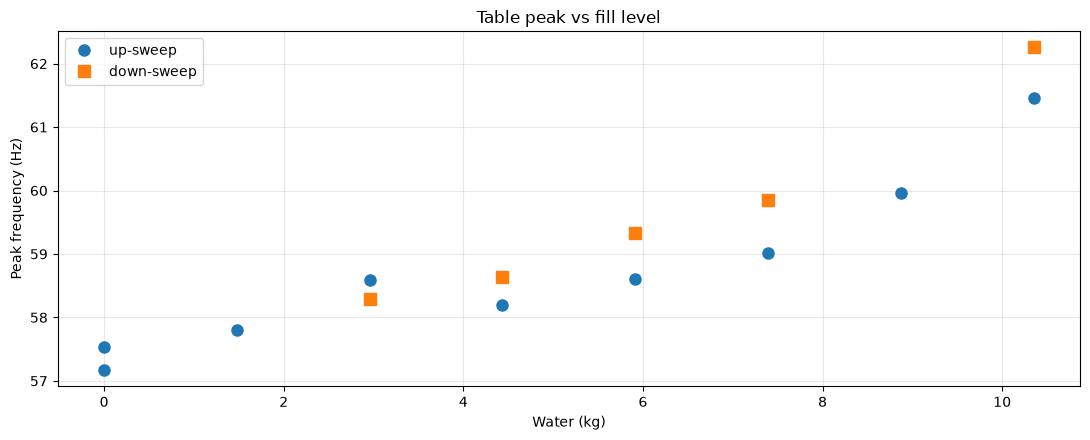

In [5]:
rows = []
for r in sorted(primary, key=(lambda r: (r["water_g"], r["trial"]))):
    if r["n_taps"] == 0:
        continue
    m = (r["f"] >= PEAK_BAND[0]) & (r["f"] <= PEAK_BAND[1])
    rows.append(dict(fill=r["lvl"], water_g=r["water_g"], trial=r["trial"],
                     when=hhmm(r), sweep=r["sweep"], mount=r["mount"],
                     n_taps=r["n_taps"],
                     f_peak=tk.peak_freq(r["f"], r["amp"], PEAK_BAND),
                     amp=r["amp"][m].max()))

peaks = pd.DataFrame(rows)
print(peaks.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

if not peaks.empty:
    fig, ax = plt.subplots()
    for sweep, mk in (("up", "o"), ("down", "s")):
        g = peaks[peaks["sweep"] == sweep]
        ax.plot(g["water_g"] / 1000, g["f_peak"], mk, ms=8, label=f"{sweep}-sweep")
    ax.set_xlabel("Water (kg)"); ax.set_ylabel("Peak frequency (Hz)")
    ax.set_title("Table peak vs fill level")
    ax.legend()
    plt.tight_layout(); plt.show()

## 5. The mass check

For a mass on a spring, f = (1/2π)·√(k/m), which rearranges to

$$\frac{1}{f^2} = \frac{4\pi^2}{k}\,(m_{bucket} + m_{water})$$

So `1/f²` against water mass should be a **straight line**, and the ratio of
its intercept to its slope is the bucket's own mass. That number is not
fitted to anything you measured — it falls out of the line — so comparing it
to the bucket you can put on a scale is a real test of whether this is a
mass effect at all.

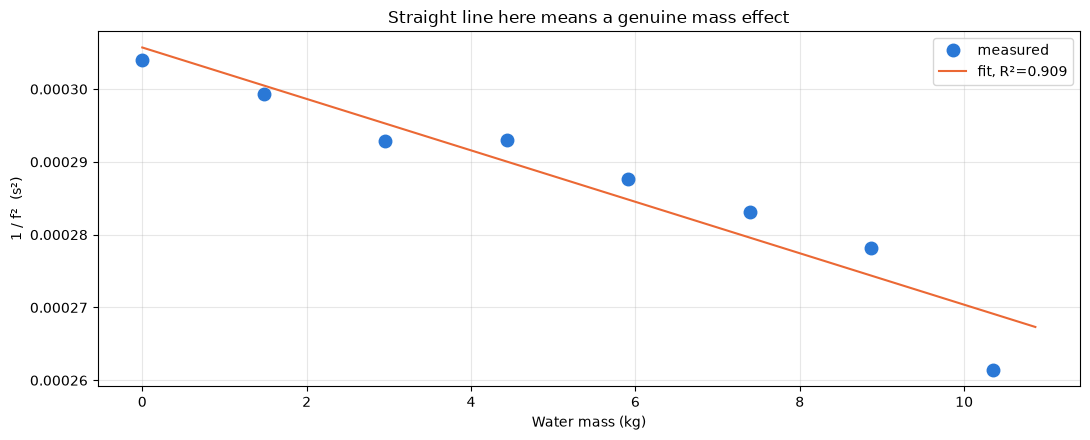

R²                    0.909
stiffness k           nan N/m
bucket mass, inferred    nan kg
bucket mass, actual     0.84 kg

-> Non-physical. The peak is not tracking mass.


In [6]:
fit = None
if not peaks.empty and peaks["water_g"].nunique() >= 3:
    agg = peaks.groupby("water_g", as_index=False)["f_peak"].mean()
    m_water = agg["water_g"].values / 1000.0
    inv_f2 = 1.0 / agg["f_peak"].values ** 2

    fit = linregress(m_water, inv_f2)
    k_est = 4 * np.pi ** 2 / fit.slope if fit.slope > 0 else np.nan
    m_bucket_est = fit.intercept / fit.slope if fit.slope > 0 else np.nan

    fig, ax = plt.subplots()
    ax.plot(m_water, inv_f2, "o", ms=9, color="#2a78d6", label="measured")
    xs = np.linspace(0, m_water.max() * 1.05, 50)
    ax.plot(xs, fit.slope * xs + fit.intercept, "-", color="#eb6834",
            label=f"fit, R²={fit.rvalue ** 2:.3f}")
    ax.set_xlabel("Water mass (kg)"); ax.set_ylabel("1 / f²  (s²)")
    ax.set_title("Straight line here means a genuine mass effect")
    ax.legend()
    plt.tight_layout(); plt.show()

    print(f"R²                    {fit.rvalue ** 2:.3f}")
    print(f"stiffness k           {k_est:,.0f} N/m")
    print(f"bucket mass, inferred {m_bucket_est:6.2f} kg")
    print(f"bucket mass, actual   {BUCKET_KG:6.2f} kg")

    if not np.isfinite(m_bucket_est) or m_bucket_est <= 0:
        print("\n-> Non-physical. The peak is not tracking mass.")
    elif abs(m_bucket_est - BUCKET_KG) < 0.5 * BUCKET_KG:
        print("\n-> Within 50% of the real bucket. Consistent with a mass effect.")
    else:
        print("\n-> Off by more than 50%. Something else is moving the peak, or")
        print("   more of the water is decoupled from the bucket than assumed.")
else:
    print("Need at least 3 fill levels before this means anything.")

## 6. Two boards: the ratio dip

If you recorded with `--port2`, each fill level has a spectrum from each
board. Their **ratio** is what you actually want: the tap's strength appears
in both numerator and denominator, so it divides out, and what survives is
the difference between the two mounting points.

The two ESP32s have independent crystals and their timestamps mean nothing to
each other. That is fine here. Both files cover the same taps, so averaging
each board's spectrum over its own taps gives two estimates of the same
excitation ensemble, and their ratio is meaningful without sample-level
alignment. The only requirement is that both boards caught roughly the same
taps, which the tap counts below confirm.

Clock rates differ by a fraction of a percent, so board B's spectrum gets
interpolated onto board A's frequency grid before dividing.

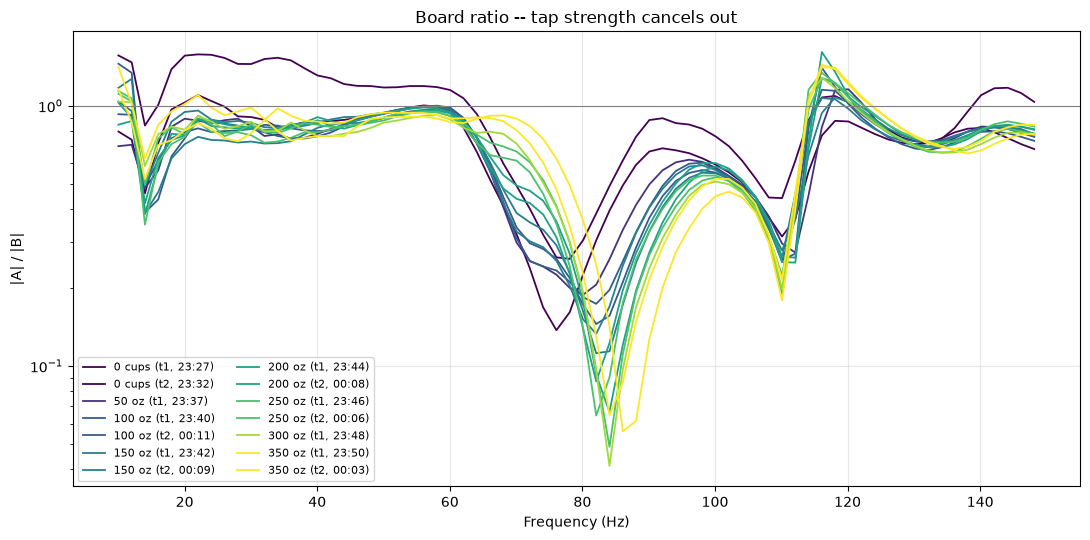

  fill  water_g  trial  when  f_peak  f_dip  peak   dip  taps_a  taps_b
0 cups        0      1 23:27  22.022 78.078 1.574 0.258      26      26
0 cups        0      2 23:32  22.022 76.076 1.098 0.137      27      27
 50 oz     1478      1 23:37 120.120 80.080 1.156 0.187      29      29
100 oz     2957      1 23:40 116.116 82.082 1.399 0.173      29      29
100 oz     2957      2 00:11  10.010 82.082 1.449 0.145      29      29
150 oz     4436      1 23:42 116.116 82.082 1.070 0.133      29      29
150 oz     4436      2 00:09  12.012 82.082 1.268 0.112      29      29
200 oz     5914      1 23:44 116.116 82.082 1.607 0.087      29      29
200 oz     5914      2 00:08 116.116 84.084 1.279 0.067      29      29
250 oz     7392      1 23:46 116.116 82.082 1.337 0.064      29      29
250 oz     7392      2 00:06 116.116 84.084 1.270 0.049      29      29
300 oz     8871      1 23:48 116.116 84.084 1.281 0.041      30      30
350 oz    10349      1 23:50 116.116 84.084 1.404 0.065      30 

In [7]:
# Paired on the capture stamp (see tk.captures): A and B from one recording
# always end up together, and repeats at the same fill can't be mixed up.
two = {(bs[next(iter(bs))]["water_g"], bs[next(iter(bs))]["trial"], stamp): bs
       for stamp, bs in tk.captures(runs).items() if len(bs) >= 2}

ratio_rows = []
if not two:
    print("Only one board per run. Record with --port2 to enable this section.")
else:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    levels2 = sorted({k[0] for k in two})
    for (wg, trial, stamp), boards in sorted(two.items()):
        when = hhmm({"stamp": stamp})
        la, lb = sorted(boards)[:2]
        a, b = boards[la], boards[lb]
        lvl = a["lvl"]
        if a["n_taps"] == 0 or b["n_taps"] == 0:
            print(f"{lvl} t{trial} {when}: a board found no taps, skipped")
            continue
        if abs(a["n_taps"] - b["n_taps"]) > 0.25 * max(a["n_taps"], b["n_taps"]):
            print(f"{lvl} t{trial} {when}: tap counts differ a lot "
                  f"({la}={a['n_taps']}, {lb}={b['n_taps']}) -- ratio is unreliable")

        ratio = tk.ratio_spectrum(a, b)

        m = (a["f"] >= PEAK_BAND[0]) & (a["f"] <= PEAK_BAND[1])
        frac = levels2.index(wg) / max(len(levels2) - 1, 1)
        ax.semilogy(a["f"][m], ratio[m], lw=1.3,
                    color=plt.get_cmap("viridis")(frac),
                    label=f"{lvl} (t{trial}, {when})")

        fb, rb = a["f"][m], ratio[m]
        ratio_rows.append(dict(fill=lvl, water_g=wg, trial=trial, when=when,
                               f_peak=fb[int(np.argmax(rb))],
                               f_dip=fb[int(np.argmin(rb))],
                               peak=rb.max(), dip=rb.min(),
                               taps_a=a["n_taps"], taps_b=b["n_taps"]))

    ax.axhline(1.0, color="0.5", lw=0.8)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel(f"|{la}| / |{lb}|")
    ax.set_title("Board ratio -- tap strength cancels out")
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout(); plt.show()

    rdf = pd.DataFrame(ratio_rows)
    print(rdf.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
    print("\nTrack whichever of f_peak / f_dip moves steadily with water,")
    print("then put that band into PEAK_BAND and rerun from step 4.")

## 7. Mount check

Same tap, two ways of attaching the board. Where the curves agree, the
mounting is faithful. Where they part company, you are looking at the tape,
not the table. That divergence point is the honest upper frequency limit for
everything above.

In [8]:
mounts = peaks["mount"].unique() if not peaks.empty else []
if len(mounts) < 2:
    print("Only one mounting recorded. Redo one fill level with the board "
          "clamped or glued and pass --mount \"clamped\" to compare.")
else:
    by_level = {}
    for r in runs:
        by_level.setdefault(r["water_g"], []).append(r)
    shared = [c for c, rs in by_level.items()
              if len({x["mount"] for x in rs}) > 1]

    if not shared:
        print("No fill level was recorded with two different mountings.")
    else:
        c = shared[0]
        fig, ax = plt.subplots(figsize=(11, 5))
        for r in by_level[c]:
            if r["n_taps"] == 0:
                continue
            m = r["f"] <= 500
            ax.semilogy(r["f"][m], r["amp"][m], lw=1.2,
                        label=f"mount={r['mount']}")
        ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Amplitude (g, arb.)")
        ax.set_title(f"Mount comparison at {by_level[c][0]['lvl']}")
        ax.legend()
        plt.tight_layout(); plt.show()
        print("Trust nothing above the frequency where these separate.")

Only one mounting recorded. Redo one fill level with the board clamped or glued and pass --mount "clamped" to compare.


## 8. Data quality

If `dropped` or `late` are non-zero the timestamps have gaps and the spectra are suspect. If `clip` is non-zero the accelerometer railed.

In [9]:
qual = []
for r in runs:
    t = r["df"]["t_s"].values
    dt = np.diff(t)
    stats = {"run": r["name"], "fill": r["lvl"], "taps": r["n_taps"],
             "fs_Hz": round(r["fs"], 1),
             "dt_jitter_us": round(np.std(dt) * 1e6, 1),
             "gaps>3dt": int(np.sum(dt > 3 * np.median(dt)))}
    for key in ("dropped", "late", "mpu_clip", "i2c_err"):
        if key in r["meta"]:
            stats[key] = r["meta"][key]
    qual.append(stats)

qdf = pd.DataFrame(qual)
print(qdf.to_string(index=False))

# The firmware's own dropped/late counts are the authority: they mean samples
# were actually lost. A few tens of microseconds of jitter at 1 kHz, or a
# handful of long loop iterations, costs nothing.
n_rows = {r["name"]: len(r["df"]) for r in runs}


def suspect(row):
    for key in ("dropped", "late"):
        if str(row.get(key, "0")) not in ("0", "nan"):
            return True
    if row["gaps>3dt"] > 0.005 * n_rows[row["run"]]:
        return True
    return row["dt_jitter_us"] > 250


bad = qdf[qdf.apply(suspect, axis=1)] if len(qdf) else qdf
if len(bad):
    print("\nThese runs lost samples -- treat their spectra with care:")
    print(bad.to_string(index=False))
else:
    print("\nNo samples lost on any run.")
    print("(A few 'gaps' and some microseconds of jitter are normal: the")
    print(" board timestamps each sample, so a long loop shows up as a")
    print(" wider gap rather than a missing reading.)")

                                     run   fill  taps  fs_Hz  dt_jitter_us  gaps>3dt dropped late mpu_clip i2c_err
run_cups000_trial1_A_20260920_232712.csv 0 cups    26  999.0          88.8        14       0    0        0       0
run_cups000_trial1_B_20260920_232712.csv 0 cups    26 1000.0          33.3         2       0    0        0       0
run_cups000_trial2_A_20260920_233211.csv 0 cups    27  999.0          88.9        14       0    0        0       0
run_cups000_trial2_B_20260920_233211.csv 0 cups    27 1000.0          52.5         2       0    0        0       0
  run_oz050_trial1_A_20260920_233736.csv  50 oz    29  999.0          88.9        14       0    0        0       0
  run_oz050_trial1_B_20260920_233736.csv  50 oz    29 1000.0          34.8         2       0    0        0       0
  run_oz100_trial1_A_20260920_234054.csv 100 oz    29  999.0          88.9        14       0    0        0       0
  run_oz100_trial1_B_20260920_234054.csv 100 oz    29 1000.0          33.3      

## Next

If the data is clean, go to **`02_predictor.ipynb`** with the same `DATA_DIR`:
the feature survey, the predictor comparison and `predict_water`.